# $\text{Taller - Aprendizaje Supervisado de Clasificación}$
##$\text{Predicción de Niveles de Riesgo en la Salud Materna}$
---
## $\text{Tabla de Contenido}$
1. $\text{Importar Librerías}$
2. $\text{Introducción a la Clasificación}$
2. $\text{Comprendiendo los Datos}$
   - Descripción de Variables
   - Carga de Datos
   - Limpieza de los Datos
3. $\text{Visualización de los Datos usando Gráficos}$
6. $\text{Preparación de Variables (X e y)}$
7. $\text{División de los Datos en Conjuntos de Entrenamiento y Prueba}$
8. $\text{Entrenamiento con k-Nearest Neighbors (KNN)}$
9. $\text{Entrenamiento con Regresión Logística}$
10. $\text{Entrenamiento con Support Vector Classifier (SVC)}$
11. $\text{Comparación y Evaluación de Modelos}$


## 1. $\text{Importar Librerías}$

In [ ]:
# Librerías para manejo de datos
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Modelos y preprocesamiento
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

## 2. $\text{Introducción a la Clasificación}$

El aprendizaje supervisado de clasificación implica predecir una etiqueta categórica para un conjunto de datos. En este taller, utilizaremos el Maternal Health Risk Data Set, que contiene información sobre pacientes embarazadas.

Nuestro objetivo es predecir el nivel de riesgo de salud materna (clase categórica) basado en características médicas y fisiológicas.

Modelos a utilizar:

- k-Nearest Neighbors (KNN).
- Regresión Logística.
- Support Vector Classifier (SVC).


## 3. $\text{Comprendiendo los Datos}$

### Descripción del Dataset:

El dataset contiene información sobre la salud materna de pacientes embarazadas. Cada fila representa un caso clínico.

- `Age`:	Edad de la paciente (en años).
- `SystolicBP`:	Presión arterial sistólica (mmHg).
- `DiastolicBP`:	Presión arterial diastólica (mmHg).
- `BS`:	Nivel de azúcar en sangre (mmol/L).
- `BodyTemp`:	Temperatura corporal (en grados Celsius).
- `HeartRate`:	Ritmo cardíaco (en latidos por minuto).
- **`RiskLevel`:**	Nivel de riesgo de salud materna: Bajo, Medio o Alto.


### Carga de datos:


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Cargar el dataset

df = pd.read_csv('/content/drive/MyDrive/UNAL/Semestre III/ML/Datas/Maternal Health Risk Data Set.csv')

### Limpieza de los Datos

Verifique si hay valores faltantes y si hay haga las imputaciones necesarias.

In [ ]:
# Verificación de valores faltantes
df.info()

# Revisión de primeros datos
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1014 entries, 0 to 1013
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          1014 non-null   int64  
 1   SystolicBP   1014 non-null   int64  
 2   DiastolicBP  1014 non-null   int64  
 3   BS           1014 non-null   float64
 4   BodyTemp     1014 non-null   float64
 5   HeartRate    1014 non-null   int64  
 6   RiskLevel    1014 non-null   object 
dtypes: float64(2), int64(4), object(1)
memory usage: 55.6+ KB


,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
0,25,130,80,15.0,98.0,86,high risk
1,35,140,90,13.0,98.0,70,high risk
2,29,90,70,8.0,100.0,80,high risk
3,30,140,85,7.0,98.0,70,high risk
4,35,120,60,6.1,98.0,76,low risk


In [ ]:
df['RiskLevel'].unique()

array(['high risk', 'low risk', 'mid risk'], dtype=object)

In [ ]:
# Copia, para graficar el boxenplot de las características
data = df.copy()


# Codificar la variable categórica
# Mapeo explícito para codificar los niveles de riesgo

risk_mapping = {'low risk': 0, 'mid risk': 1, 'high risk': 2}
data['RiskLevel'] = data['RiskLevel'].map(risk_mapping)


# Escalado de datos
scaler = StandardScaler()
numeric_features = ['Age', 'SystolicBP', 'DiastolicBP', 'BS', 'BodyTemp', 'HeartRate']
data[numeric_features] = scaler.fit_transform(data[numeric_features])

In [ ]:
data.head()

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
0,-0.361738,0.913396,0.255023,1.905890,-0.485215,1.446956,2
1,0.380777,1.457027,0.975539,1.298340,-0.485215,-0.532088,2
2,-0.064732,-1.261127,-0.465493,-0.220537,0.973884,0.704815,2
3,0.009519,1.457027,0.615281,-0.524312,-0.485215,-0.532088,2
4,0.380777,0.369765,-1.186009,-0.797710,-0.485215,0.210054,0


## 5. $\text{Análisis Exploratorio de Datos (EDA)}$



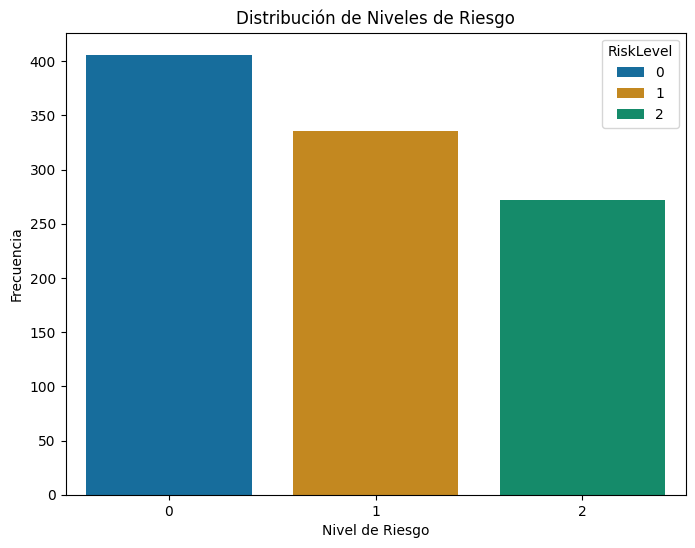

In [ ]:
# Distribución de niveles de riesgo (countplot)
plt.figure(figsize=(8, 6))
sns.countplot(data= data, x="RiskLevel", palette = 'colorblind', hue = 'RiskLevel')
plt.title("Distribución de Niveles de Riesgo")
plt.xlabel("Nivel de Riesgo")
plt.ylabel("Frecuencia")
plt.show()

<Figure size 800x600 with 0 Axes>

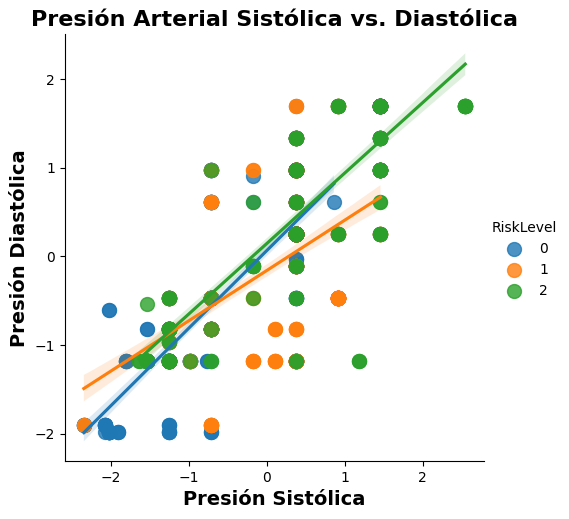

In [ ]:
# Relación entre presión arterial sistólica y diastólica (lmplot)
plt.figure(figsize=(8, 6))
g = sns.lmplot(data = data, x='SystolicBP', y='DiastolicBP',
                hue='RiskLevel', scatter_kws={'s': 100}, facet_kws={'legend_out': True})
plt.title("Presión Arterial Sistólica vs. Diastólica", fontsize=16, fontweight='bold')
plt.xlabel("Presión Sistólica", fontsize=14, fontweight='bold')
plt.ylabel("Presión Diastólica", fontsize=14, fontweight='bold')
plt.show()

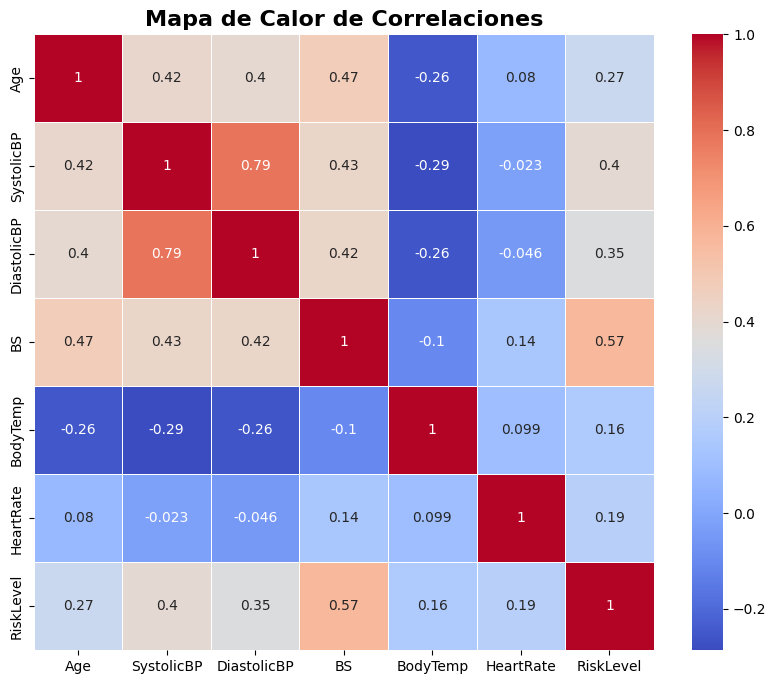

In [ ]:
# Haga un heatmap de las correlaciones

plt.figure(figsize=(10, 8))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm', linewidths=0.5)
plt.title("Mapa de Calor de Correlaciones", fontsize=16, fontweight='bold')
plt.show()

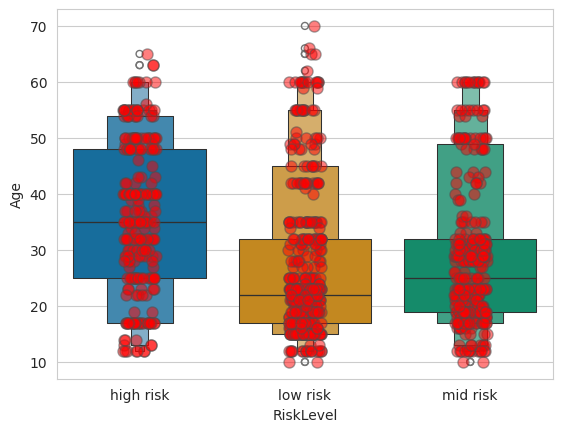

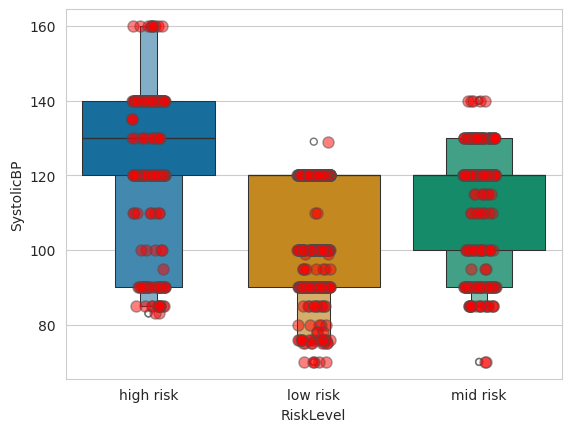

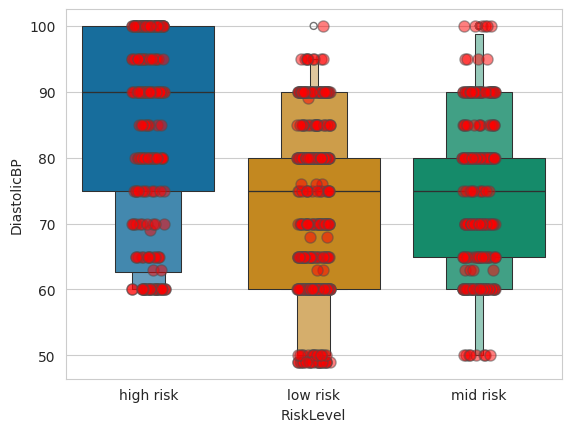

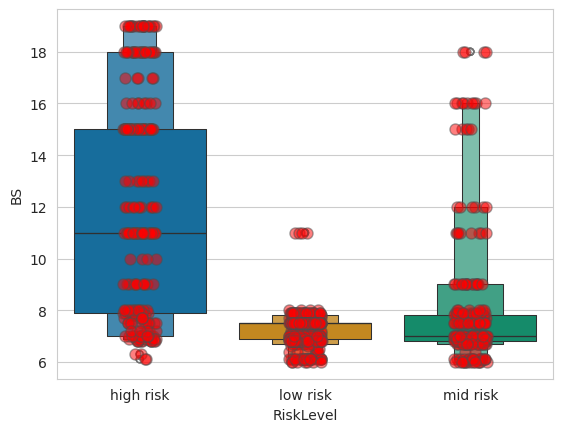

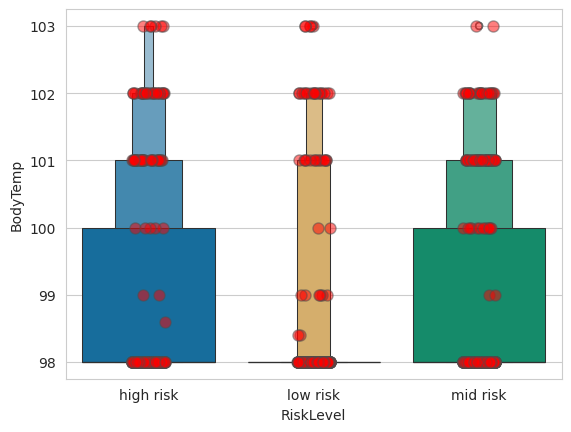

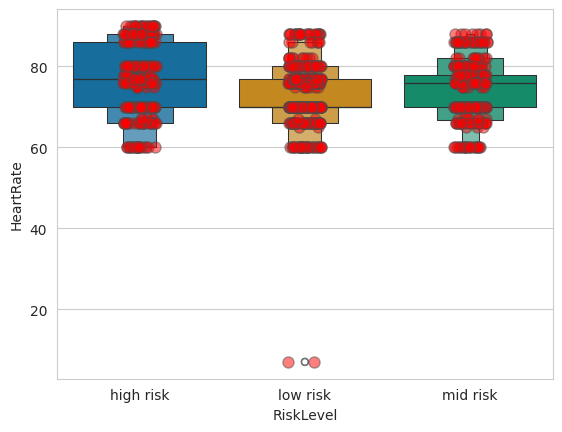

In [ ]:
# Hacer un stripplot y un boxeplot, para cada columna vs el RiskLevel

# Iterar sobre todas las columnas del DataFrame
for columna in df.columns:
    if columna != 'RiskLevel':  # Evitar usar 'RiskLevel' como variable 'y'
        # Graficar Stripplot (en vez de Swarmplot, que puede ser demasiado denso)
        sns.stripplot(x=df["RiskLevel"], y=df[columna], color="red", dodge=True, alpha=0.5,
                      size=8, linewidth=1)

        # Graficar Boxenplot con 'hue' asignado correctamente
        sns.boxenplot(x=df["RiskLevel"], y=df[columna], hue=df["RiskLevel"], palette='colorblind')

        # Mostrar el gráfico
        plt.show()


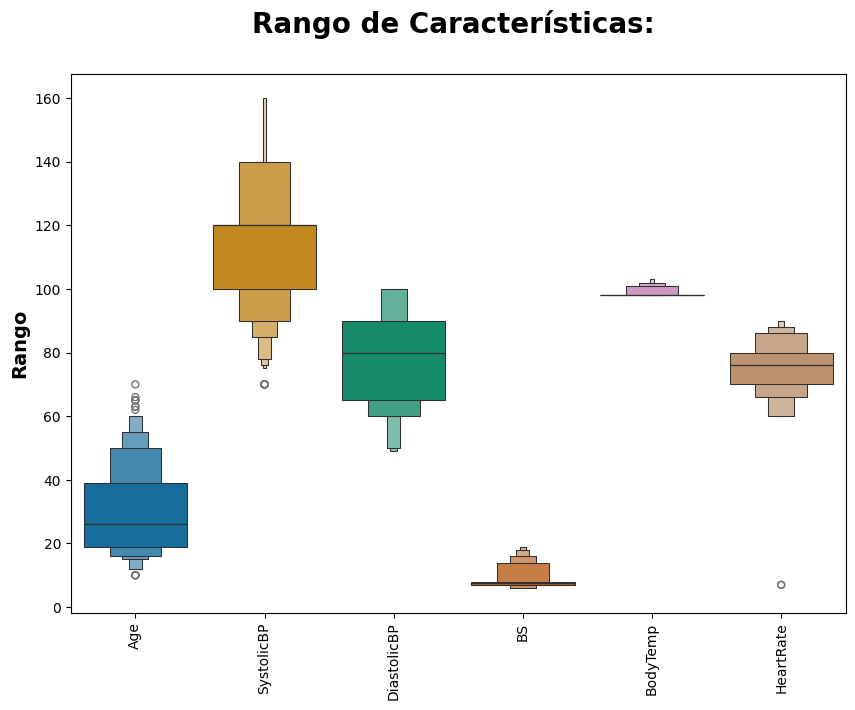

In [ ]:
# Mostrar el rango de todas las caracterísitcas con un boxenplot
plt.figure(figsize=(10,7))
sns.boxenplot(data = df,palette = 'colorblind')
plt.title('Rango de Características: \n', fontsize=20, fontweight='bold')
plt.ylabel('Rango', fontsize=14, fontweight='bold')
plt.xticks(rotation=90)
plt.show()

## 6. $\text{Preparación de Variables (X e y)}$


In [ ]:
# Separar las variables independientes (X) y dependientes (y)
X = data.iloc[:, :-1].values
y = data.iloc[:, -1].values

print(X.shape, y.shape)

(1014, 6) (1014,)


## 7. $\text{División de los Datos en Conjuntos de Entrenamiento y Prueba}$


In [ ]:
# División en conjunto de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.2, random_state=47)

## 8. $\text{Entrenamiento con k-Nearest Neighbors (KNN)}$


El mejor valor de k es: 1


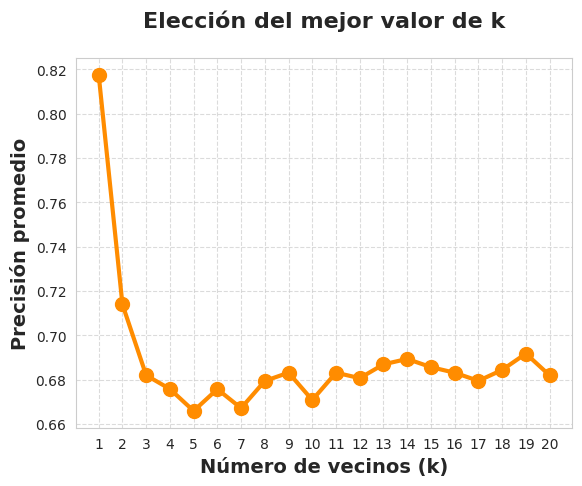

In [ ]:
from sklearn.model_selection import cross_val_score

# Definir un rango de valores para k
k_values = range(1, 21)  # Probar k desde 1 hasta 20
cv_scores = []

# Realizar validación cruzada para cada valor de k
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train, y_train, cv=10, scoring='accuracy')  # 10-fold cross-validation
    cv_scores.append(scores.mean())

# Encontrar el mejor valor de k
best_k = k_values[cv_scores.index(max(cv_scores))]
print(f"El mejor valor de k es: {best_k}")


plt.plot(k_values, cv_scores, marker='o', linestyle='-', color='darkorange', markersize=10, linewidth=3)
plt.xlabel('Número de vecinos (k)', fontsize=14, fontweight='bold')
plt.ylabel('Precisión promedio', fontsize=14, fontweight='bold')
plt.title('Elección del mejor valor de k\n', fontsize=16, fontweight='bold', loc='center')
plt.xticks(range(1,21, 1))
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

Accuracy: 0.83

Matriz de Confusión (KNN):
 [[69  8  4]
 [10 59  3]
 [ 7  3 40]]

Reporte de Clasificación (KNN):
               precision    recall  f1-score   support

           0       0.80      0.85      0.83        81
           1       0.84      0.82      0.83        72
           2       0.85      0.80      0.82        50

    accuracy                           0.83       203
   macro avg       0.83      0.82      0.83       203
weighted avg       0.83      0.83      0.83       203



Text(70.72222222222221, 0.5, 'Valores Reales')

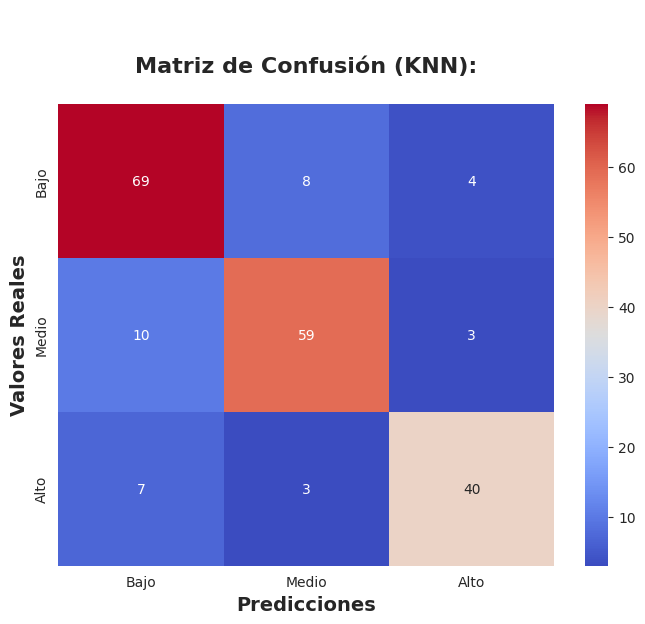

In [ ]:
# Instanciar el modelo
knn = KNeighborsClassifier(n_neighbors=1)

# Entrenar el modelo
knn.fit(X_train, y_train)

# Predicción
y_pred_knn = knn.predict(X_test)

# Evaluación
accuracy_knn = accuracy_score(y_test, y_pred_knn)
print(f"Accuracy: {accuracy_knn:.2f}\n")

print("Matriz de Confusión (KNN):\n", confusion_matrix(y_test, y_pred_knn))
print("\nReporte de Clasificación (KNN):\n", classification_report(y_test, y_pred_knn))

# Graficar matriz confusión
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred_knn), annot=True, fmt='d', cmap='coolwarm',
            xticklabels=['Bajo', 'Medio', 'Alto'], yticklabels=['Bajo', 'Medio', 'Alto'])
plt.title('\n\nMatriz de Confusión (KNN):\n', fontsize=16, fontweight='bold')
plt.xlabel('Predicciones', fontsize=14, fontweight='bold')
plt.ylabel('Valores Reales', fontsize=14, fontweight='bold')


## 9. $\text{Entrenamiento con Regresión Logística}$


Accuracy: 0.64

Matriz de Confusión (Logistic Regression):
 [[66 13  2]
 [46 19  7]
 [ 1  4 45]]

Reporte de Clasificación (Logistic Regression):
               precision    recall  f1-score   support

           0       0.58      0.81      0.68        81
           1       0.53      0.26      0.35        72
           2       0.83      0.90      0.87        50

    accuracy                           0.64       203
   macro avg       0.65      0.66      0.63       203
weighted avg       0.63      0.64      0.61       203



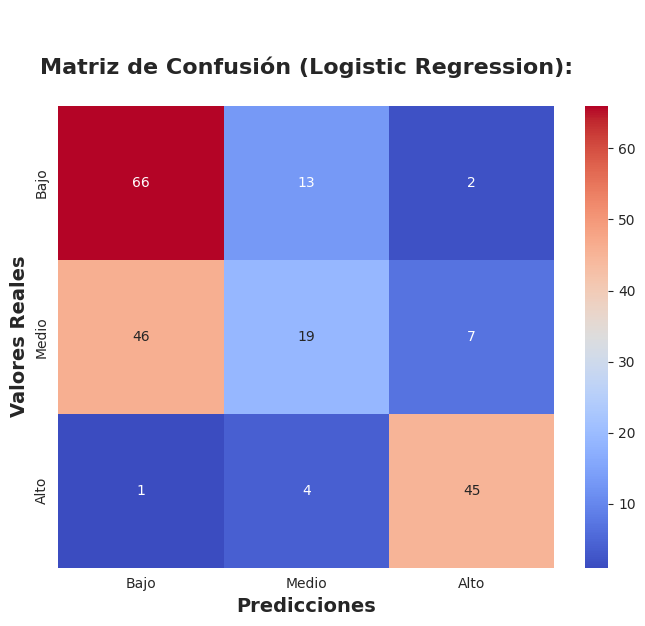

In [ ]:
# Instanciar el modelo
log_reg = LogisticRegression(max_iter=1000)

# Entrenar el modelo
log_reg.fit(X_train, y_train)

# Predicción
y_pred_log = log_reg.predict(X_test)

# Evaluación
accuracy_log = accuracy_score(y_test, y_pred_log)
print(f"Accuracy: {accuracy_log:.2f}\n")

print("Matriz de Confusión (Logistic Regression):\n", confusion_matrix(y_test, y_pred_log))
print("\nReporte de Clasificación (Logistic Regression):\n", classification_report(y_test, y_pred_log))

# Graficar la matriz de confusión
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred_log), annot=True, fmt='d', cmap='coolwarm',
            xticklabels=['Bajo', 'Medio', 'Alto'], yticklabels=['Bajo', 'Medio', 'Alto'])
plt.title('\n\nMatriz de Confusión (Logistic Regression):\n', fontsize=16, fontweight='bold')
plt.xlabel('Predicciones', fontsize=14, fontweight='bold')
plt.ylabel('Valores Reales', fontsize=14, fontweight='bold')
plt.show()

## 10. $\text{Entrenamiento con Support Vector Classifier (SVC)}$



=== Kernel: linear ===
Accuracy: 0.64
Reporte de Clasificación:
               precision    recall  f1-score   support

           0       0.59      0.80      0.68        81
           1       0.51      0.29      0.37        72
           2       0.84      0.86      0.85        50

    accuracy                           0.64       203
   macro avg       0.65      0.65      0.63       203
weighted avg       0.62      0.64      0.61       203



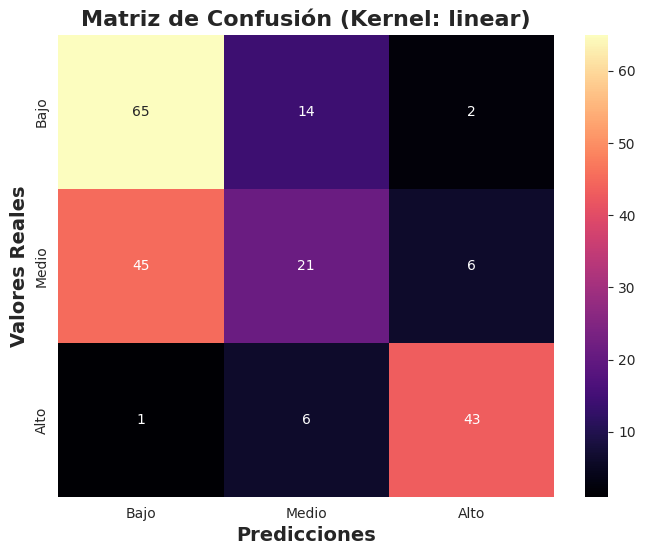


=== Kernel: poly ===
Accuracy: 0.60
Reporte de Clasificación:
               precision    recall  f1-score   support

           0       0.51      0.95      0.67        81
           1       0.70      0.10      0.17        72
           2       0.86      0.74      0.80        50

    accuracy                           0.60       203
   macro avg       0.69      0.60      0.54       203
weighted avg       0.67      0.60      0.52       203



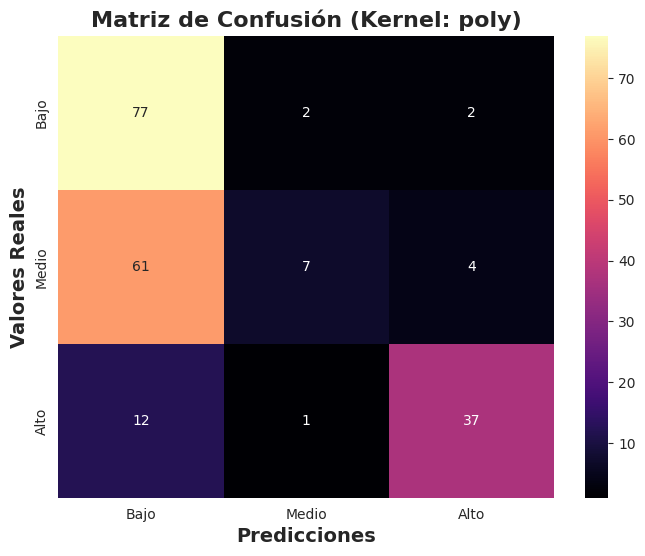


=== Kernel: rbf ===
Accuracy: 0.68
Reporte de Clasificación:
               precision    recall  f1-score   support

           0       0.60      0.84      0.70        81
           1       0.67      0.31      0.42        72
           2       0.86      0.96      0.91        50

    accuracy                           0.68       203
   macro avg       0.71      0.70      0.67       203
weighted avg       0.69      0.68      0.65       203



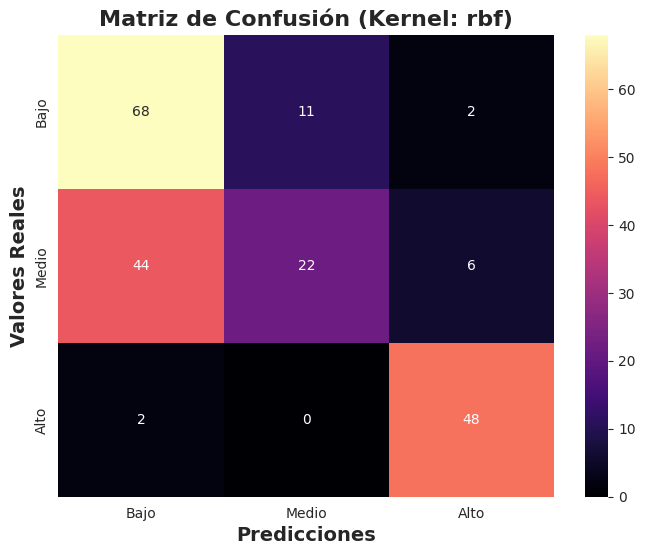


=== Kernel: sigmoid ===
Accuracy: 0.63
Reporte de Clasificación:
               precision    recall  f1-score   support

           0       0.59      0.85      0.70        81
           1       0.57      0.28      0.37        72
           2       0.73      0.76      0.75        50

    accuracy                           0.63       203
   macro avg       0.63      0.63      0.61       203
weighted avg       0.62      0.63      0.60       203



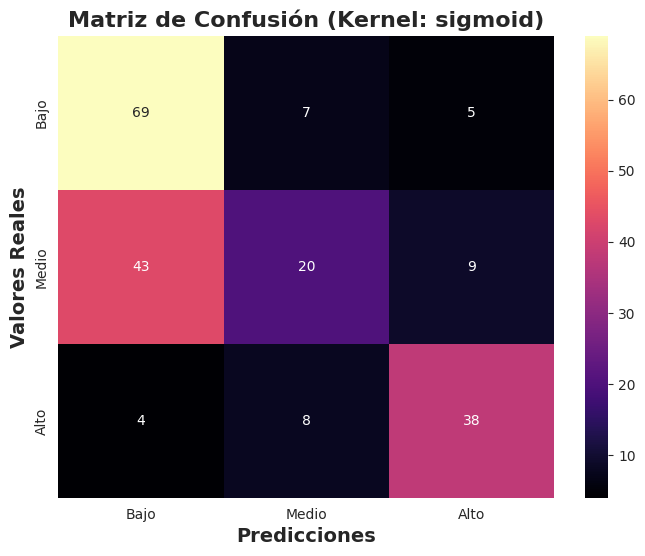


=== Comparación de Kernels ===
Kernel: linear
  Accuracy: 0.64

Kernel: poly
  Accuracy: 0.60

Kernel: rbf
  Accuracy: 0.68

Kernel: sigmoid
  Accuracy: 0.63


El kernel ganador en términos de accuracy es: rbf con un accuracy de 0.68


In [ ]:
# Lista de kernels a probar
kernels = ['linear', 'poly', 'rbf', 'sigmoid']

# Diccionario para almacenar resultados
results = {}

best_accuracy = 0  # Para almacenar el mejor accuracy
best_kernel = ''   # Para almacenar el kernel con el mejor accuracy

for kernel in kernels:
    print(f"\n=== Kernel: {kernel} ===")

    # Instanciar el modelo con el kernel actual
    svc = SVC(kernel=kernel, random_state=42)

    # Entrenar el modelo
    svc.fit(X_train, y_train)

    # Predicción
    y_pred = svc.predict(X_test)

    # Evaluación
    accuracy = accuracy_score(y_test, y_pred)
    print(f"Accuracy: {accuracy:.2f}")
    print("Reporte de Clasificación:\n", classification_report(y_test, y_pred))

    # Guardar resultados
    results[kernel] = {
        "accuracy": accuracy,
        "classification_report": classification_report(y_test, y_pred, output_dict=True),
        "confusion_matrix": confusion_matrix(y_test, y_pred)
    }

    # Graficar la matriz de confusión
    plt.figure(figsize=(8, 6))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='magma',
                xticklabels=['Bajo', 'Medio', 'Alto'], yticklabels=['Bajo', 'Medio', 'Alto'])
    plt.title(f'Matriz de Confusión (Kernel: {kernel})', fontsize=16, fontweight='bold')
    plt.xlabel('Predicciones', fontsize=14, fontweight='bold')
    plt.ylabel('Valores Reales', fontsize=14, fontweight='bold')
    plt.show()

    # Actualizar el mejor kernel si el accuracy es mayor
    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_kernel = kernel

# Comparación de resultados
print("\n=== Comparación de Kernels ===")
for kernel, metrics in results.items():
    print(f"Kernel: {kernel}")
    print(f"  Accuracy: {metrics['accuracy']:.2f}")
    print()

# Guardar el ganador en accuracy_svc
accuracy_svc = best_kernel
print(f"\nEl kernel ganador en términos de accuracy es: {accuracy_svc} con un accuracy de {best_accuracy:.2f}")


In [ ]:
# Como El kernel ganador en términos de accuracy es: rbf con un accuracy de 0.68, lo vuelvo a instanciar:

svc = SVC(kernel=accuracy_svc, random_state=47)
svc.fit(X_train, y_train)
y_pred_svc = svc.predict(X_test)

## 11. $\text{Comparación y Evaluación de Modelos}$

Accuracy KNN: 0.8276
Accuracy Logistic Regression: 0.6404
Accuracy SVC: 0.6798


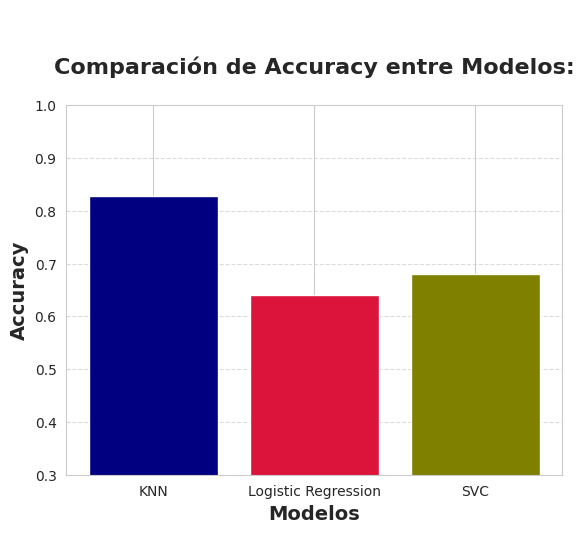

In [ ]:
# Calcular accuracy para cada modelo
acc_knn = accuracy_score(y_test, y_pred_knn)
acc_log = accuracy_score(y_test, y_pred_log)
acc_svc = accuracy_score(y_test, y_pred_svc)

print(f"Accuracy KNN: {acc_knn:.4f}")
print(f"Accuracy Logistic Regression: {acc_log:.4f}")
print(f"Accuracy SVC: {acc_svc:.4f}")

# Visualización de comparación
modelos = ['KNN', 'Logistic Regression', 'SVC']
precisiones = [acc_knn, acc_log, acc_svc]

plt.bar(modelos, precisiones, color=['navy', 'crimson', 'olive'])
plt.title("\n\nComparación de Accuracy entre Modelos:\n", fontsize=16, fontweight='bold')
plt.xlabel("Modelos", fontsize=14, fontweight='bold')
plt.ylabel("Accuracy", fontsize=14, fontweight='bold')
plt.ylim(0.3, 1.0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()
